This code includes tasks 1, 2, and 3. 
When you run all blocks, the code will prompt you twice with the question: 
"Do you want to see the verification result (say 'yes') or the result of question 1 (say 'no')?" 
The reason for two prompts is that verification is performed for both Task 1 and Task 2.

- To view the verification result for Task 1, respond "yes" to the first prompt.
- To view the verification result for Task 2, respond "yes" to the second prompt.

Verification details:
- Task 1: I reproduced the structure presented in Tüken, A. (2019)'s paper. You can compare 
the circular frequencies (rad/sec) and mode shapes from the paper with my code’s output.
- Task 2: Since this task involves calculating the moment of inertia and centroid 
considering corrosion, I set corrosion = 0 for verification purposes. Then, I calculated 
the centroid and moment of inertia for W14*120, which can be compared for validation.

In [25]:
# =============================================================================
# 1) Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.interpolate import make_interp_spline

##  ----------- Question 1: Variation in live load portion ------------------------------

### Note: When you execute the following block, python ask you a question to see the verification result or result for question 1.

In [26]:
# =============================================================================
# 2) Ask the audience whether they want to see the verification result or result of question 1
# =============================================================================
response = input("Do you want to see the verification result(say yes) or result of question 1(say no)?: ").strip().lower()

if response == "yes":
    # Loop for "yes" response
    print("You chose 'yes'. Running the verification result loop...")
    # Verificaiton for the reference: 
    # Tüken, A. (2019). Dynamic Response Analysis of a 3-story shear frame subjected to harmonic loading: An analytical approach. Uludağ Üniversitesi Mühendislik Fakültesi Dergisi, 24(2), 725-734.
    # -------------------
    # 2) Column/Material Properties and assumptions(Inputs)
    # -------------------
    EI1L = 152000 # 1: first floor, L:Left, R:Right
    EI1R = 152000
    EI2L = 152000
    EI2R = 152000
    EI3L = 152000
    EI3R = 152000

    # Story heights (m):
    h1 = 4 
    h2 = 4
    h3 = 4

    # Dead Mass
    mass = 45000 # kg
    m1_dead = mass   
    m2_dead = mass
    m3_dead = mass/2

    # Coefficient for live to dead load - we need to consider 1 to remove coefficient in validation. 
    coeff = 1

    # live to dead(we don't have live load)
    m1_live = 0 # m1_dead / coeff
    m2_live = 0 # m2_dead / coeff
    m3_live = 0 # m3_dead / coeff

    # We won't vary the live-load portion alpha for verification mode.
    num_point = 1
    max_live_portion = 1
    min_live_portion = 1

    # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
    k1L = 12.0 * EI1L / (h1**3) # 1:First floor, L:Left, R:Right
    k1R = 12.0 * EI1R / (h1**3)
    k2L = 12.0 * EI2L / (h2**3)
    k2R = 12.0 * EI2R / (h2**3)
    k3L = 12.0 * EI3L / (h3**3)
    k3R = 12.0 * EI3R / (h3**3)

    # Correct result(I got these values from original reference)
    w1_correct = 2.5359 *np.sqrt(EI1L/(mass*h1**3))
    w2_correct = 6.9282 *np.sqrt(EI2L/(mass*h2**3))
    w3_correct = 9.4641 *np.sqrt(EI3L/(mass*h3**3))



elif response == "no":
    # Loop for "no" response
    print("You chose 'no'. solve the quesion 1(Modal Analysis when we have variation in live load)")
    # Example (Question 1)
    # -------------------
    # 2) Column/Material Properties and assumptions(Inputs)
    # -------------------
    E   = 29000.0       # ksi (typical steel)- ksi
    # For a W14x120, strong-axis I
    I1L  = 1380.0         # in^4 
    I1R  = 1380.0         # in^4 
    I2L  = 1380.0         # in^4 
    I2R  = 1380.0         # in^4 
    I3L  = 1380.0         # in^4 
    I3R  = 1380.0         # in^4 

    # Story heights:
    h1 = 180.0  # e.g., 15 ft = 180 in
    h2 = 180.0
    h3 = 180.0

    # Dead Mass
    m1_dead = 0.24   # kip*s^2/in
    m2_dead = 0.24
    m3_dead = 0.12

    # Coefficient for live to dead load
    coeff = 3

    # live to dead
    m1_live = m1_dead / coeff
    m2_live = m2_dead / coeff
    m3_live = m3_dead / coeff

    # We will vary the live-load portion alpha in [0.25, 0.75]
    num_point = 5
    max_live_portion = 0.75
    min_live_portion = 0.25

    # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
    k1L = 12.0 * E * I1L / (h1**3)
    k1R = 12.0 * E * I1R / (h1**3)
    k2L = 12.0 * E * I2L / (h2**3)
    k2R = 12.0 * E * I2R / (h2**3)
    k3L = 12.0 * E * I3L / (h3**3)
    k3R = 12.0 * E * I3R / (h3**3)
    
else:
    # Handle invalid input
    print("Invalid response. Please type 'yes' or 'no'.")

You chose 'yes'. Running the verification result loop...


In [27]:
# =============================================================================
# 3) Define K and M for 3 SDF
# =============================================================================
def build_mass_matrix(m1, m2, m3):
    """
    Returns a 3x3 diagonal mass matrix [M].
    """
    return np.diag([m1, m2, m3])

def build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R):
    """
    Returns a 3x3 stiffness matrix [K] for a 3-DOF shear building.
    """
    # First floor
    k1 = k1L+k1R
    # Second floor
    k2 = k2L+k2R
    # Third floor
    k3 = k3L+k3R
    
    return np.array([
        [k1 + k2,   -k2,       0   ],
        [    -k2,   k2 + k3,   -k3 ],
        [     0,       -k3,    k3  ]
    ])

--------- Result of Tüken, A. (2019) paper(Verification)--------------------------------
 Correct Circular frequencies (rad/sec) 1 is: 0.5825828205070932
 Correct Circular frequencies (rad/sec) 2 is: 1.591644109403858
 Correct Circular frequencies (rad/sec) 3 is: 2.1742269299109513
 Mode shapes (floor1, floor2, floor3) normalized:
 Mode 1: [0.5       0.866    1]
 Mode 2: [-1        0        1]
 Mode 3: [ 0.5       -0.866  1]
--------------------------------- My result -------------------------------
Matrix M = [[45000.     0.     0.]
 [    0. 45000.     0.]
 [    0.     0. 22500.]]

Matrix K = [[114000. -57000.      0.]
 [-57000. 114000. -57000.]
 [     0. -57000.  57000.]]

eigvals(𝜆=𝜔2)= [0.33940231 2.53333333 4.72726436]
eigvecs(mode shapes)= [[-1.92450090e-03  3.84900179e-03  1.92450090e-03]
 [-3.33333333e-03  4.95468513e-19 -3.33333333e-03]
 [-3.84900179e-03 -3.84900179e-03  3.84900179e-03]]

alpha = 1.00
Circular frequencies (rad/sec): [0.58258245 1.59164485 2.1742273 ]
Frequenci

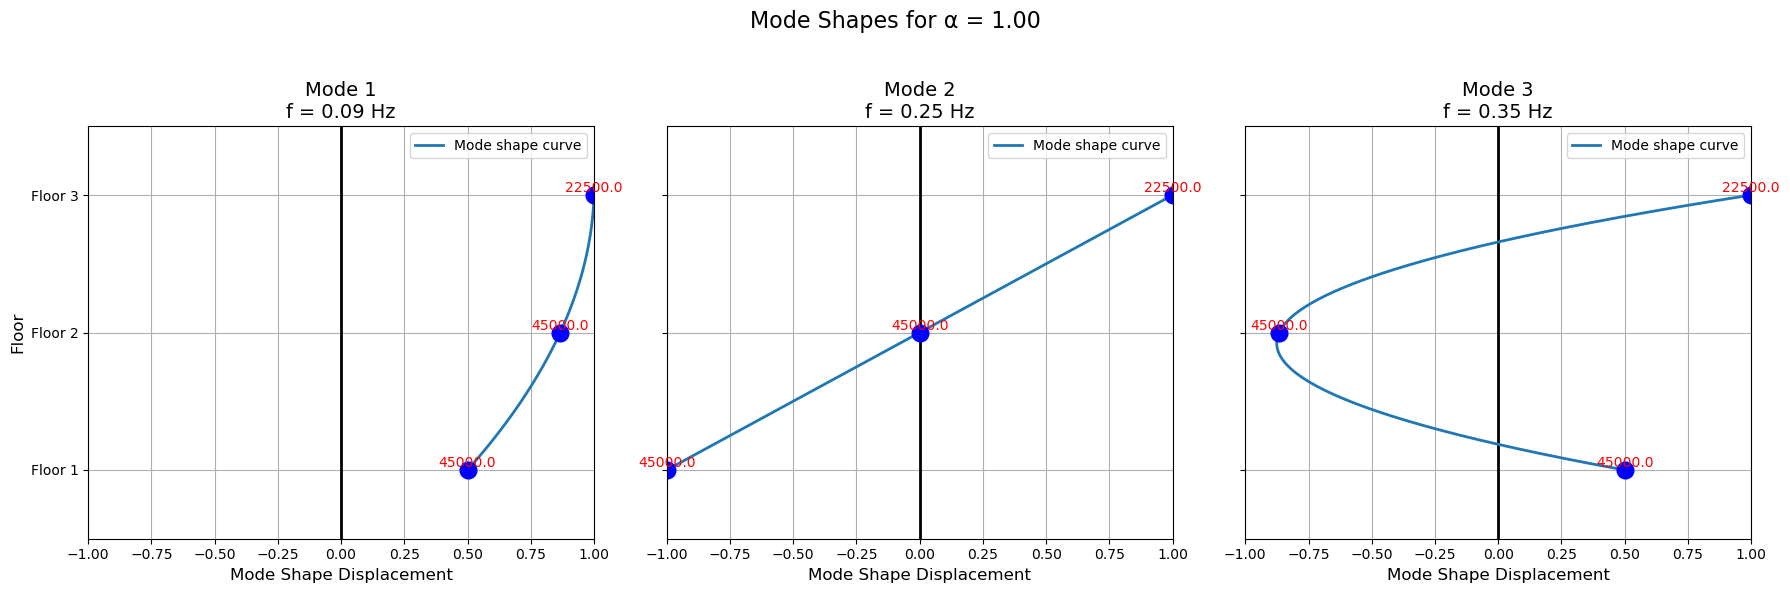

In [28]:
# =============================================================================
# 4) Modal Analysis
# =============================================================================
# Print the result for verification
if response == "yes":
    print("--------- Result of Tüken, A. (2019) paper(Verification)--------------------------------")
    print(f" Correct Circular frequencies (rad/sec) 1 is: {w1_correct}")
    print(f" Correct Circular frequencies (rad/sec) 2 is: {w2_correct}")
    print(f" Correct Circular frequencies (rad/sec) 3 is: {w3_correct}")
    print(" Mode shapes (floor1, floor2, floor3) normalized:")
    print(" Mode 1: [0.5       0.866    1]")
    print(" Mode 2: [-1        0        1]")
    print(" Mode 3: [ 0.5       -0.866  1]")


# We will vary the live-load portion alpha in [0.25, 0.75].
alpha_values = np.linspace(min_live_portion, max_live_portion, num_point)  # For example 6 points: 0.25, 0.35, ..., 0.75


# Prepare containers to store mode shape data for plotting.
# For each mode (mode 1, mode 2, mode 3), we store a list of tuples (alpha, mode_shape vector)
mode_shapes_all = {1: [], 2: [], 3: []}
                   

# Prepare arrays to store results
freqs_array = []  # will store [alpha, f1, f2, f3] in each row

for alpha in alpha_values:
    # Compute total masses for this alpha:
    m1 = m1_dead + alpha*m1_live
    m2 = m2_dead + alpha*m2_live
    m3 = m3_dead + alpha*m3_live

    # Build M, K
    M = build_mass_matrix(m1, m2, m3)
    K = build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R)

    print("--------------------------------- My result -------------------------------")
    print(f"Matrix M = {M}")
    print("")
    print(f"Matrix K = {K}")
    print("")

    # Transform the generalized problem to a standard one:
    A = np.linalg.inv(M).dot(K)

    #  eigvals correspond to 𝜆=𝜔2 (the squared circular frequencies), and eigvecs are the corresponding mode shapes (eigenvectors)
    # Symmetric (Hermitian) and positive definite, for vibration and modal analysis we should use eigh
    eigvals, eigvecs = eigh(K, M)
    print(f"eigvals(𝜆=𝜔2)= {eigvals}")
    print(f"eigvecs(mode shapes)= {eigvecs}")
    print("")

    # Compute circular frequencies and convert to natural freq in Hz
    # Why abs: In dynamic problems, the eigenvalues λ should theoretically be nonnegative since they represent ω2
    # squared circular frequencies). However, due to small round‑off errors in numerical computations, we might occasionally see a very tiny negative eigenvalue. 
    w = np.sqrt(np.abs(eigvals))           # rad/s
    freq = w / (2.0*np.pi)                 # Hz

    # Store the results:
    freqs_array.append([alpha, freq[0], freq[1], freq[2]])

    # Print out mode shapes (normalized so that the top entry = 1, etc.)
    # Let’s say we want to keep them consistent: for each mode i, we can normalize so enforce a consistent scaling such that the third floor’s value is always +1
    mode_shapes = []
    for i in range(3):
        # Make a copy to avoid modifying the original array in place
        mode_i = eigvecs[:, i].copy()
        # If the third floor's value (index 2) is negative, flip the sign of the entire vector
        if mode_i[2] < 0:
            mode_i = -mode_i
        # Normalize so that the third floor's value becomes 1
        mode_i /= mode_i[2]
        mode_shapes.append(mode_i)
        # Store for plotting: key is mode index (1-based)
        mode_shapes_all[i+1].append((alpha, mode_i))



    # Print results for the current alpha value:
    print(f"alpha = {alpha:.2f}")
    print("Circular frequencies (rad/sec):", w)
    print("Frequencies (Hz):", freq)
    print("")
    print("Mode shapes (floor1, floor2, floor3) normalized:")
    for i, shape in enumerate(mode_shapes, start=1):
        print(f"  Mode {i}: {shape}")
    print("")

    # -------------------
    # Plot mode shapes by using quadratic spkine interpolation to show the mode shape curve
    # -------------------
    num_modes = 3
    
    # Define the vertical positions for each floor.
    # For clarity, we use 1 = Floor 1 (bottom), 2 = Floor 2, and 3 = Floor 3 (top).
    floors = np.array([1, 2, 3])
    # Store the corresponding lumped mass values for annotation.
    mass_values = [m1, m2, m3]

    # Plot settings: create one subplot per mode.
    fig, axes = plt.subplots(1, num_modes, figsize=(18, 6), sharey=True)
    mode_names = ['Mode 1', 'Mode 2', 'Mode 3']

    # For smooth interpolation of the mode shape curve, we use a quadratic spline interpolation.
    # With only three points, a quadratic (k=2) spline gives a smooth curve.
    for i in range(num_modes):
        ax = axes[i]

        # For each mode, take the mode shape corresponding to the final alpha value.
        # Here, mode_shapes_all[i+1] is a list of tuples (alpha, mode_shape vector) and [-1][1] selects the mode shape from the last alpha in the list.
        mode_shape_i = mode_shapes_all[i+1][-1][1]
        
        # Create a fine vertical grid for smooth curve (using the floor positions as the parameter).
        y_fine = np.linspace(floors.min(), floors.max(), 300)
        # Create the quadratic spline (k=2) mapping floor (y) to displacement (x).
        spline = make_interp_spline(floors, mode_shape_i, k=2)
        x_fine = spline(y_fine)
        
        # Draw a vertical reference line representing the structure (at x = 0).
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        
        # Plot the smooth mode shape curve (x_fine vs. y_fine)
        ax.plot(x_fine, y_fine, '-', linewidth=2, label='Mode shape curve')
        
        # Plot the lumped masses as circles at each floor (using the mode shape displacement at that floor)
        for j, (x_val, y_val) in enumerate(zip(mode_shape_i, floors)):
            ax.plot(x_val, y_val, 'o', markersize=12, color='blue')
            # Annotate the point with the lumped mass value (formatted to 1 decimal place)
            ax.text(x_val, y_val, f'\n{mass_values[j]:.1f}', ha='center', va='bottom', fontsize=10, color='red')
        
        # Set axis labels and title.
        rep_freq = freqs_array[-1]  # This is something like [alpha, f1, f2, f3]
        # This ensures that for mode i (i = 0, 1, 2), we use rep_freq[i+1].
        ax.set_title(f'{mode_names[i]}\nf = {rep_freq[i+1]:.2f} Hz', fontsize=14)
        ax.set_xlabel('Mode Shape Displacement', fontsize=12)
        if i == 0:
            ax.set_ylabel('Floor', fontsize=12)
        # Adjust y-axis to show all floors comfortably.
        ax.set_ylim(0.5, 3.5)
        ax.set_yticks(floors)
        ax.set_xlim(-1, 1) # to compare better figures
        ax.set_yticklabels(['Floor 1', 'Floor 2', 'Floor 3'])
        ax.legend()
        ax.grid(True)

    plt.suptitle(f'Mode Shapes for α = {alpha:.2f}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if response != "yes":
    # Convert frequency summary to NumPy array for further processing or plotting.
    freqs_array = np.array(freqs_array)
    print("Summary of frequencies vs. alpha:")
    print(" alpha |   f1(Hz)    f2(Hz)    f3(Hz)")
    for row in freqs_array:
        print(f"{row[0]:6.2f} | {row[1]:9.4f} {row[2]:9.4f} {row[3]:9.4f}")


    # Plot each frequency vs alphas
    # Extract the alpha values and frequencies for each mode
    alpha = freqs_array[:, 0]
    freq_mode1 = freqs_array[:, 1]
    freq_mode2 = freqs_array[:, 2]
    freq_mode3 = freqs_array[:, 3]

    # -----------------------------
    # Plot for Mode 1
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(alpha, freq_mode1, 'o-', linewidth=2, markersize=8, color='blue')
    plt.xlabel("α (Live Load Fraction)", fontsize=12)
    plt.ylabel("Frequency Mode 1 (Hz)", fontsize=12)
    plt.title("Frequency vs. α for Mode 1", fontsize=14)
    plt.grid(True)
    plt.tight_layout()

    # -----------------------------
    # Plot for Mode 2
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(alpha, freq_mode2, 'o-', linewidth=2, markersize=8, color='green')
    plt.xlabel("α (Live Load Fraction)", fontsize=12)
    plt.ylabel("Frequency Mode 2 (Hz)", fontsize=12)
    plt.title("Frequency vs. α for Mode 2", fontsize=14)
    plt.grid(True)
    plt.tight_layout()

    # -----------------------------
    # Plot for Mode 3
    # -----------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(alpha, freq_mode3, 'o-', linewidth=2, markersize=8, color='red')
    plt.xlabel("α (Live Load Fraction)", fontsize=12)
    plt.ylabel("Frequency Mode 3 (Hz)", fontsize=12)
    plt.title("Frequency vs. α for Mode 3", fontsize=14)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

####  ---------------------------------------------------------- Question 2: Exposure to chlorides ------------------------------------------------------------------

In [29]:
# =============================================================================
# Section Dimensions for W14×120 (inches)
# =============================================================================
depth = 14.5                # Overall depth (total height) in inches
top_width = 14.7            # Width of the top flange in inches
top_thickness = 0.94        # Thickness of the top flange in inches
bottom_width = 14.7         # Width of the bottom flange in inches
bottom_thickness = 0.94     # Thickness of the bottom flange in inches
web_thickness = 0.59        # Thickness of the web in inches
# Fillet radius is given as 0.6 in but is ignored in this analysis

### Note: When you execute the following block, python ask you a question to see the verification result or result for question 1.
Verification for Moment of Inertia and Centroid (y_bar) from bottom: To check my calculation, I just change the corrosion_rate_mm_per_year=0 for verification, and executed the rest of the code and compare Moment of Inertia and Centroid (y_bar) from bottom with our result . 

In [30]:
# =============================================================================
# Ask the audience whether they want to see the verification result or result of question 1
# =============================================================================
response = input("Do you want to see the verification result(say yes) or result of question 2(say no)?: ").strip().lower()

# exposure time in years
years = 20                         

if response == "yes":
    # =============================================================================
    # Step 1: Just put corrosion_rate_mm_per_year = 0 to compare the moment of inertia and centroid from bottom with correct ones.
    # =============================================================================
        corrosion_rate_mm_per_year = 0     # corrosion rate (mm/year) - we don't have corrosion for verification
        nototal_corrosion_mm = corrosion_rate_mm_per_year * years
        corrosion_inch = nototal_corrosion_mm / 25.4  # Convert mm to inches

elif response == "no":
    print("You chose 'no'. solve the quesion 2(Exposure to Corrosion)")
    # =============================================================================
    # Step 1: Calculate the corrosion loss in inches.
    # =============================================================================
    corrosion_rate_mm_per_year = 0.25  # corrosion rate (mm/year)

    total_corrosion_mm = corrosion_rate_mm_per_year * years
    corrosion_inch = total_corrosion_mm / 25.4  # Convert mm to inches
    # Expected value: approximately 0.197 inch

else:
    # Handle invalid input
    print("Invalid response. Please type 'yes' or 'no'.")

In [31]:
# =============================================================================
# Step 2: Update the flange thickness for the corroded flange.
#         (Assume the top flange is corroded.)
# =============================================================================
# The bottom flange remains unchanged.
top_thickness_new = top_thickness - corrosion_inch
print(f"top_thickness_new = {top_thickness_new}")

top_thickness_new = 0.94


In [32]:
# =============================================================================
# Step 3: Calculate the area center (centroid) of the modified section.
#
# We model the W-section as three rectangular parts:
#   - Bottom flange: width = bottom_width, thickness = bottom_thickness.
#   - Web: width = web_thickness, height = depth - bottom_thickness - top_thickness_new.
#   - Top flange (corroded): width = top_width, thickness = top_thickness_new.
#
# We assume the reference (y = 0) at the bottom of the section.
# =============================================================================
# Compute the web height (note: using the new top flange thickness)
web_height = depth - bottom_thickness - top_thickness_new

# Areas of the components:
area_bottom = bottom_width * bottom_thickness
area_web = web_thickness * web_height
area_top = top_width * top_thickness_new

# Compute the centroids (y-coordinates) of each rectangle:
# Bottom flange: centroid at half of its thickness.
y_bottom = bottom_thickness / 2.0
# Web: centroid at (bottom flange thickness + half of web height)
y_web = bottom_thickness + web_height / 2.0
# Top flange: centroid at (bottom flange thickness + web height + half of top flange thickness)
y_top = bottom_thickness + web_height + top_thickness_new / 2.0

# Total area:
total_area = area_bottom + area_web + area_top

# Overall centroid (y_bar) using the area-weighted average:
y_bar = (area_bottom*y_bottom + area_web*y_web + area_top*y_top) / total_area

In [33]:
# =============================================================================
# Step 4: Calculate the moment of inertia of the modified section about its centroid.
#
# For each rectangular piece (i = bottom, web, top) compute:
#    I_self = (b * h^3) / 12  (moment of inertia about its own centroid)
# Then shift using the parallel axis theorem:
#    I = I_self + A * d^2,  where d is the distance between the piece’s centroid and y_bar.
# Finally, sum the contributions.
# =============================================================================
# For the bottom flange:
I_bottom_self = (bottom_width * (bottom_thickness ** 3)) / 12.0
d_bottom = y_bar - y_bottom
I_bottom = I_bottom_self + area_bottom * (d_bottom ** 2)

# For the web:
I_web_self = (web_thickness * (web_height ** 3)) / 12.0
d_web = y_web - y_bar
I_web = I_web_self + area_web * (d_web ** 2)

# For the top flange (corroded):
I_top_self = (top_width * (top_thickness_new ** 3)) / 12.0
d_top = y_top - y_bar
I_top = I_top_self + area_top * (d_top ** 2)

# Total moment of inertia about the centroid:
I_total = I_bottom + I_web + I_top

In [34]:
# =============================================================================
# Step 5: Mass reduction: This lost mass is subtracted from the floor’s lumped mass m1, so that our mass matrix correctly reflects the reduction in mass due to corrosion.
# =============================================================================
# Calculate lost area 
lost_area = corrosion_inch * top_width  # in^2

# Compute lost volume along the entire column height 
h_story_1 = 180.0   # in, story height
lost_volume = lost_area * h_story_1   # in^3

# Compute lost mass 
density_steel = 0.283   # lb/in^3  (I aausme this)
lost_weight_lb = lost_volume * density_steel   # in pounds
lost_weight_kip = lost_weight_lb / 1000          # in kips

# Convert weight to mass (using dynamic units, mass in kip·s²/in, this is the same scale of mass in question)
g = 386.4  # in/s^2
lost_mass = lost_weight_kip / g   # in kip·s²/in

print("Lost mass from corrosion (kip·s²/in): {:.4f}".format(lost_mass))

# Update m1 (the lumped mass for Story 1)
m1_dead = 0.24
m1_new = m1_dead - lost_mass

print("m1_new (kip·s²/in): {:.4f}".format(m1_new))


Lost mass from corrosion (kip·s²/in): 0.0000
m1_new (kip·s²/in): 0.2400


In [35]:
# =============================================================================
# Step 6: Inputs
# =============================================================================
if response == "yes":
    # Loop for "yes" response
    print("You chose 'yes'. Running the verification result loop...")
    # Verificaiton for the reference: 
    # Tüken, A. (2019). Dynamic Response Analysis of a 3-story shear frame subjected to harmonic loading: An analytical approach. Uludağ Üniversitesi Mühendislik Fakültesi Dergisi, 24(2), 725-734.
    # -------------------
    # 2) Column/Material Properties and assumptions(Inputs)
    # -------------------
    EI1L = 152000 # 1: first floor, L:Left, R:Right
    EI1R = 152000
    EI2L = 152000
    EI2R = 152000
    EI3L = 152000
    EI3R = 152000

    # Story heights (m):
    h1 = 4 
    h2 = 4
    h3 = 4

    # Dead Mass
    mass = 45000 # kg
    m1_dead = mass   
    m2_dead = mass
    m3_dead = mass/2

    # Coefficient for live to dead load - we need to consider 1 to remove coefficient in validation. 
    # coeff = 1

    # live to dead(we don't have live load)
    m1_live = 0 # m1_dead / coeff
    m2_live = 0 # m2_dead / coeff
    m3_live = 0 # m3_dead / coeff

    # We won't vary the live-load portion alpha for verification mode.
    num_point = 1
    max_live_portion = 1
    min_live_portion = 1

    # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
    k1L = 12.0 * EI1L / (h1**3) # 1:First floor, L:Left, R:Right
    k1R = 12.0 * EI1R / (h1**3)
    k2L = 12.0 * EI2L / (h2**3)
    k2R = 12.0 * EI2R / (h2**3)
    k3L = 12.0 * EI3L / (h3**3)
    k3R = 12.0 * EI3R / (h3**3)

    # Correct result(I got these values from original reference)
    w1_correct = 2.5359 *np.sqrt(EI1L/(mass*h1**3))
    w2_correct = 6.9282 *np.sqrt(EI2L/(mass*h2**3))
    w3_correct = 9.4641 *np.sqrt(EI3L/(mass*h3**3))

elif response == "no":
    # Loop for "no" response
    print("You chose 'no'. solve the quesion 1(Modal Analysis when we have variation in live load)")
    # Example (Question 1)
    # -------------------
    # 2) Column/Material Properties and assumptions(Inputs)
    # -------------------
    E   = 29000.0       # ksi (typical steel)- ksi
    # For a W14x120, strong-axis I
    I1L  = 1380.0         # in^4 
    I1R  = I_total        # in^4 - Right column in story 1
    I2L  = 1380.0         # in^4 
    I2R  = 1380.0         # in^4 
    I3L  = 1380.0         # in^4 
    I3R  = 1380.0         # in^4 

    # Story heights:
    h1 = h_story_1  # 15 ft = 180 in
    h2 = 180.0
    h3 = 180.0

    # Dead Mass
    m1_dead = m1_new   # kip*s^2/in - Reduction in dad mass due to corrosion
    m2_dead = 0.24
    m3_dead = 0.12

    # Coefficient for live to dead load
    coeff = 3

    # live to dead
    m1_live = m1_dead / coeff
    m2_live = m2_dead / coeff
    m3_live = m3_dead / coeff

    # #  We won't vary the live-load portion alpha for verification mode.
    # num_point = 1
    # max_live_portion = 1
    # min_live_portion = 1

    # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
    k1L = 12.0 * E * I1L / (h1**3)
    k1R = 12.0 * E * I1R / (h1**3)
    k2L = 12.0 * E * I2L / (h2**3)
    k2R = 12.0 * E * I2R / (h2**3)
    k3L = 12.0 * E * I3L / (h3**3)
    k3R = 12.0 * E * I3R / (h3**3)
    
else:
    # Handle invalid input
    print("Invalid response. Please type 'yes' or 'no'.")

You chose 'yes'. Running the verification result loop...


In [36]:
# =============================================================================
# Ste7 7: Define K and M for 3 SDOF
# =============================================================================
def build_mass_matrix(m1, m2, m3):
    """
    Returns a 3x3 diagonal mass matrix [M].
    """
    return np.diag([m1, m2, m3])

def build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R):
    """
    Returns a 3x3 stiffness matrix [K] for a 3-DOF shear building.
    """
    # First floor
    k1 = k1L+k1R
    # Second floor
    k2 = k2L+k2R
    # Third floor
    k3 = k3L+k3R
    
    return np.array([
        [k1 + k2,   -k2,       0   ],
        [    -k2,   k2 + k3,   -k3 ],
        [     0,       -k3,    k3  ]
    ])

--------- My result and correct ones for moment of inertia and centroid from bottom --------------------------------
Step 1: Corrosion loss (inches): 0.0000
Moment of Inertia (in^4) for W14×120(correct one): 1380.0
Centroid (y_bar) from bottom (inches)for W14×120(correct one): depth/2 = 7.2500
Step 2: No corrosion
Step 3: Centroid (y_bar) from bottom (inches - my calculation): 7.2500
Step 4: Moment of Inertia about the centroid (in^4 - my calculation): 1371.2385

--------- Result of Tüken, A. (2019) paper(Verification) --------------------------------
 Correct Circular frequencies (rad/sec) 1 is: 0.5825828205070932
 Correct Circular frequencies (rad/sec) 2 is: 1.591644109403858
 Correct Circular frequencies (rad/sec) 3 is: 2.1742269299109513
 Mode shapes (floor1, floor2, floor3) normalized:
 Mode 1: [0.5       0.866    1]
 Mode 2: [-1        0        1]
 Mode 3: [ 0.5       -0.866  1]
--------------------------------- My result -------------------------------
Matrix M = [[45000.     0.

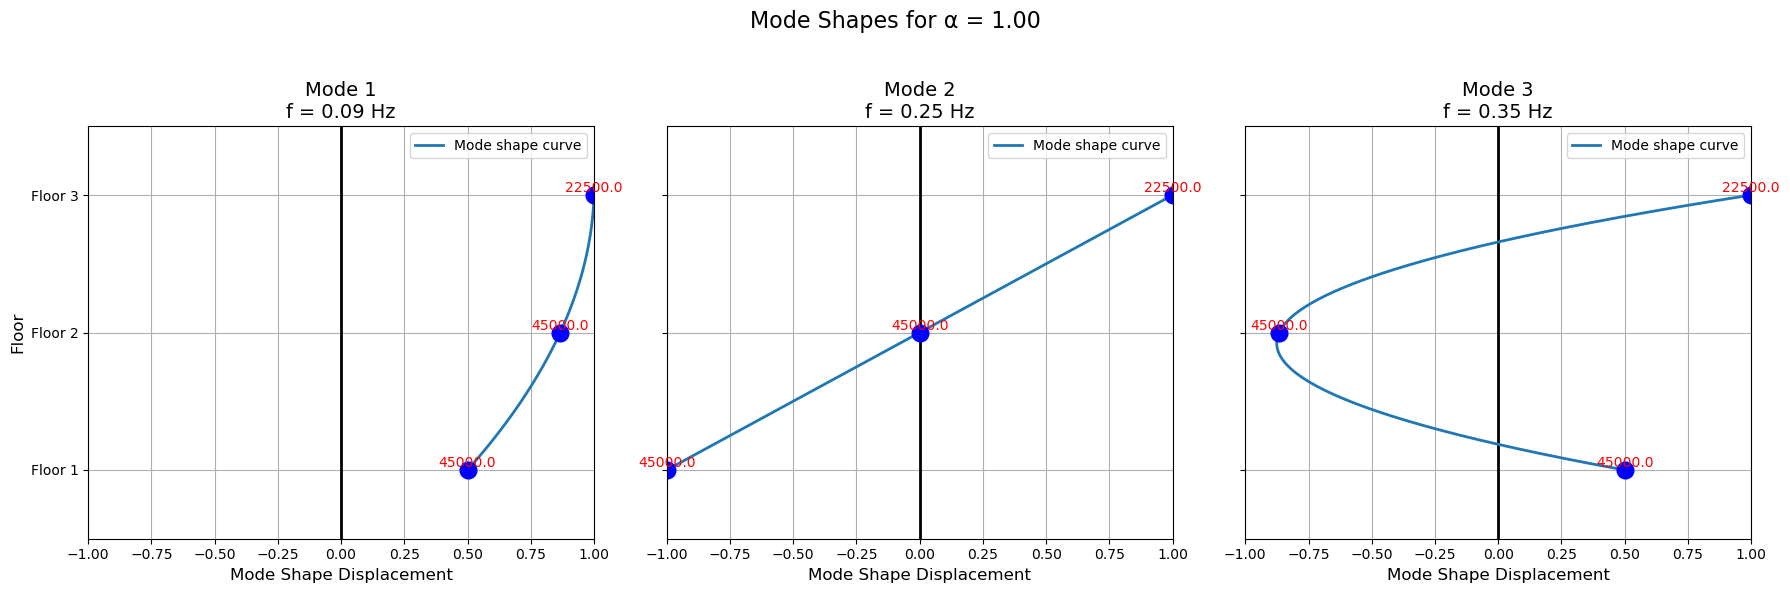

Summary of frequencies vs. alpha:
 alpha |   f1(Hz)    f2(Hz)    f3(Hz)
  1.00 |    0.0927    0.2533    0.3460


In [37]:
# Show the correct results for moment of inertia and centroid from bottom
if response == "yes":
    print("--------- My result and correct ones for moment of inertia and centroid from bottom --------------------------------")
    print("Step 1: Corrosion loss (inches): {:.4f}".format(corrosion_inch))
    print("Moment of Inertia (in^4) for W14×120(correct one): 1380.0") 
    print("Centroid (y_bar) from bottom (inches)for W14×120(correct one): depth/2 = 7.2500")
elif response == "no":
    print("Step 1: Corrosion loss (inches): {:.4f}".format(corrosion_inch))

if corrosion_rate_mm_per_year != 0:
    print("Step 2: New top flange thickness (inches): {:.4f}".format(top_thickness_new))
elif corrosion_rate_mm_per_year == 0:
    print("Step 2: No corrosion")

print("Step 3: Centroid (y_bar) from bottom (inches - my calculation): {:.4f}".format(y_bar))
print("Step 4: Moment of Inertia about the centroid (in^4 - my calculation): {:.4f}".format(I_total))
print("")

# Print the result for verification
if response == "yes":
    print("--------- Result of Tüken, A. (2019) paper(Verification) --------------------------------")
    print(f" Correct Circular frequencies (rad/sec) 1 is: {w1_correct}")
    print(f" Correct Circular frequencies (rad/sec) 2 is: {w2_correct}")
    print(f" Correct Circular frequencies (rad/sec) 3 is: {w3_correct}")
    print(" Mode shapes (floor1, floor2, floor3) normalized:")
    print(" Mode 1: [0.5       0.866    1]")
    print(" Mode 2: [-1        0        1]")
    print(" Mode 3: [ 0.5       -0.866  1]")
# =============================================================================
# 8) Modal Analysis
# =============================================================================
# Prepare containers to store mode shape data for plotting.

alpha = 1 # Do not consider the live load variation in this task

# For each mode (mode 1, mode 2, mode 3), we store a list of tuples (alpha, mode_shape vector)
mode_shapes_all = {1: [], 2: [], 3: []}
                   
# Prepare arrays to store results
freqs_array = []  # will store [alpha, f1, f2, f3] in each row

# Compute total masses for this alpha:
m1 = m1_dead + alpha*m1_live
m2 = m2_dead + alpha*m2_live
m3 = m3_dead + alpha*m3_live

# Build M, K
M = build_mass_matrix(m1, m2, m3)
K = build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R)

print("--------------------------------- My result -------------------------------")
print(f"Matrix M = {M}")
print("")
print(f"Matrix K = {K}")
print("")

# Transform the generalized problem to a standard one:
A = np.linalg.inv(M).dot(K)

#  eigvals correspond to 𝜆=𝜔2 (the squared circular frequencies), and eigvecs are the corresponding mode shapes (eigenvectors)
# Symmetric (Hermitian) and positive definite, for vibration and modal analysis we should use eigh
eigvals, eigvecs = eigh(K, M)
print(f"eigvals(𝜆=𝜔2)= {eigvals}")
print(f"eigvecs(mode shapes)= {eigvecs}")
print("")

# Compute circular frequencies and convert to natural freq in Hz
# Why abs: In dynamic problems, the eigenvalues λ should theoretically be nonnegative since they represent ω2
# squared circular frequencies). However, due to small round‑off errors in numerical computations, we might occasionally see a very tiny negative eigenvalue. 
w = np.sqrt(np.abs(eigvals))           # rad/s
freq = w / (2.0*np.pi)                 # Hz

# Store the results:
freqs_array.append([alpha, freq[0], freq[1], freq[2]])

# Print out mode shapes (normalized so that the top entry = 1, etc.)
# Let’s say we want to keep them consistent: for each mode i, we can normalize so enforce a consistent scaling such that the third floor’s value is always +1
mode_shapes = []
for i in range(3):
    # Make a copy to avoid modifying the original array in place
    mode_i = eigvecs[:, i].copy()
    # If the third floor's value (index 2) is negative, flip the sign of the entire vector
    if mode_i[2] < 0:
        mode_i = -mode_i
    # Normalize so that the third floor's value becomes 1
    mode_i /= mode_i[2]
    mode_shapes.append(mode_i)
    # Store for plotting: key is mode index (1-based)
    mode_shapes_all[i+1].append((alpha, mode_i))


# Print results for the current alpha value:
print(f"alpha = {alpha:.2f}")
print("Circular frequencies (rad/sec):", w)
print("Frequencies (Hz):", freq)
print("")
print("Mode shapes (floor1, floor2, floor3) normalized:")
for i, shape in enumerate(mode_shapes, start=1):
    print(f"  Mode {i}: {shape}")
print("")

# -------------------
# Plot mode shapes by using quadratic spkine interpolation to show the mode shape curve
# -------------------
num_modes = 3

# Define the vertical positions for each floor.
# For clarity, we use 1 = Floor 1 (bottom), 2 = Floor 2, and 3 = Floor 3 (top).
floors = np.array([1, 2, 3])
# Store the corresponding lumped mass values for annotation.
mass_values = [m1, m2, m3]

# Plot settings: create one subplot per mode.
fig, axes = plt.subplots(1, num_modes, figsize=(18, 6), sharey=True)
mode_names = ['Mode 1', 'Mode 2', 'Mode 3']

# For smooth interpolation of the mode shape curve, we use a quadratic spline interpolation.
# With only three points, a quadratic (k=2) spline gives a smooth curve.
for i in range(num_modes):
    ax = axes[i]

    # For each mode, take the mode shape corresponding to the final alpha value.
    # Here, mode_shapes_all[i+1] is a list of tuples (alpha, mode_shape vector) and [-1][1] selects the mode shape from the last alpha in the list.
    mode_shape_i = mode_shapes_all[i+1][-1][1]
    
    # Create a fine vertical grid for smooth curve (using the floor positions as the parameter).
    y_fine = np.linspace(floors.min(), floors.max(), 300)
    # Create the quadratic spline (k=2) mapping floor (y) to displacement (x).
    spline = make_interp_spline(floors, mode_shape_i, k=2)
    x_fine = spline(y_fine)
    
    # Draw a vertical reference line representing the structure (at x = 0).
    ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
    
    # Plot the smooth mode shape curve (x_fine vs. y_fine)
    ax.plot(x_fine, y_fine, '-', linewidth=2, label='Mode shape curve')
    
    # Plot the lumped masses as circles at each floor (using the mode shape displacement at that floor)
    for j, (x_val, y_val) in enumerate(zip(mode_shape_i, floors)):
        ax.plot(x_val, y_val, 'o', markersize=12, color='blue')
        # Annotate the point with the lumped mass value (formatted to 1 decimal place)
        ax.text(x_val, y_val, f'\n{mass_values[j]:.1f}', ha='center', va='bottom', fontsize=10, color='red')
    
    # Set axis labels and title.
    rep_freq = freqs_array[-1]  # This is something like [alpha, f1, f2, f3]
    # This ensures that for mode i (i = 0, 1, 2), we use rep_freq[i+1].
    ax.set_title(f'{mode_names[i]}\nf = {rep_freq[i+1]:.2f} Hz', fontsize=14)
    ax.set_xlabel('Mode Shape Displacement', fontsize=12)
    if i == 0:
        ax.set_ylabel('Floor', fontsize=12)
    # Adjust y-axis to show all floors comfortably.
    ax.set_ylim(0.5, 3.5)
    ax.set_yticks(floors)
    ax.set_xlim(-1, 1) # to compare better figures
    ax.set_yticklabels(['Floor 1', 'Floor 2', 'Floor 3'])
    ax.legend()
    ax.grid(True)

plt.suptitle(f'Mode Shapes for α = {alpha:.2f}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Convert frequency summary to NumPy array for further processing or plotting.
freqs_array = np.array(freqs_array)
print("Summary of frequencies vs. alpha:")
print(" alpha |   f1(Hz)    f2(Hz)    f3(Hz)")
for row in freqs_array:
    print(f"{row[0]:6.2f} | {row[1]:9.4f} {row[2]:9.4f} {row[3]:9.4f}")


# Save results for corrosion in new parameters to use and compare in the third task
M_corroded = M                         # mass
K_corroded = K                         # Stiff
w_corroded = w                         # Circular frequency(rad/s)
freq_corroded = freq                   # Frequencies (Hz)
mode_shapes_corroded = mode_shapes     # Mode shape

####  ---------------------------------------------------------- Question 3: Health Monitoring ------------------------------------------------------------------
I will calculate properties for two manner and compare them:

    1- Healthy: Without any live load variation and without corrosion(cause I consider the variation in the first task, I need to recalculate task 1 and consider live load portion =1).

    2- Corroded: Without any live load variation and with corrosion(We already have the result from the task 2). 

    Note: we don't have any verification for this part, so if response == yes(doing verification for whole code), the following codes won't run.

In [38]:
# We need to check this. If response would be yes, we don't execute the following blocks becasue it compare the wrong structures together. 
if response == "no":
    # Example (Question 1)
    # -------------------
    # 1 and 2 )Column/Material Properties and assumptions(Inputs)
    # -------------------
    E   = 29000.0       # ksi (typical steel)- ksi
    # For a W14x120, strong-axis I
    I1L  = 1380.0         # in^4 
    I1R  = 1380.0         # in^4 
    I2L  = 1380.0         # in^4 
    I2R  = 1380.0         # in^4 
    I3L  = 1380.0         # in^4 
    I3R  = 1380.0         # in^4 

    # Story heights:
    h1 = 180.0  # e.g., 15 ft = 180 in
    h2 = 180.0
    h3 = 180.0

    # Dead Mass
    m1_dead = 0.24   # kip*s^2/in
    m2_dead = 0.24
    m3_dead = 0.12

    # Coefficient for live to dead load
    coeff = 3

    # live to dead
    m1_live = m1_dead / coeff
    m2_live = m2_dead / coeff
    m3_live = m3_dead / coeff

    # # We will vary the live-load portion alpha in [0.25, 0.75]
    # num_point = 6
    # max_live_portion = 0.75
    # min_live_portion = 0.25

    # Compute each story stiffness (2 columns in parallel), I put stiffness here because we can change the equation if frame changes
    k1L = 12.0 * E * I1L / (h1**3)
    k1R = 12.0 * E * I1R / (h1**3)
    k2L = 12.0 * E * I2L / (h2**3)
    k2R = 12.0 * E * I2R / (h2**3)
    k3L = 12.0 * E * I3L / (h3**3)
    k3R = 12.0 * E * I3R / (h3**3)

In [39]:
# We need to check this. If response would be yes, we don't execute the following blocks becasue it compare the wrong structures together. 
if response == "no":
    # =============================================================================
    # 3) Define K and M for 3 SDF
    # =============================================================================
    def build_mass_matrix(m1, m2, m3):
        """
        Returns a 3x3 diagonal mass matrix [M].
        """
        return np.diag([m1, m2, m3])

    def build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R):
        """
        Returns a 3x3 stiffness matrix [K] for a 3-DOF shear building.
        """
        # First floor
        k1 = k1L+k1R
        # Second floor
        k2 = k2L+k2R
        # Third floor
        k3 = k3L+k3R
        
        return np.array([
            [k1 + k2,   -k2,       0   ],
            [    -k2,   k2 + k3,   -k3 ],
            [     0,       -k3,    k3  ]
        ])

In [40]:
# We need to check this. If response would be yes, we don't execute the following blocks becasue it compare the wrong structures together. 
if response == "no":
    # =============================================================================
    # 4) Modal Analysis
    # =============================================================================
    # We will vary the live-load portion alpha in [0.25, 0.75].
    # alpha_values = np.linspace(min_live_portion, max_live_portion, num_point)  # For example 6 points: 0.25, 0.35, ..., 0.75
    alpha = 1

    # Prepare containers to store mode shape data for plotting.
    # For each mode (mode 1, mode 2, mode 3), we store a list of tuples (alpha, mode_shape vector)
    mode_shapes_all = {1: [], 2: [], 3: []}
                    

    # Prepare arrays to store results
    freqs_array = []  # will store [alpha, f1, f2, f3] in each row


    # Compute total masses for this alpha:
    m1 = m1_dead + alpha*m1_live
    m2 = m2_dead + alpha*m2_live
    m3 = m3_dead + alpha*m3_live

    # Build M, K
    M = build_mass_matrix(m1, m2, m3)
    K = build_stiffness_matrix(k1L, k1R, k2L, k2R, k3L, k3R)

    print("--------------------------------- My result(healthy) -------------------------------")
    print(f"Matrix M = {M}")
    print("")
    print(f"Matrix K = {K}")
    print("")

    # Transform the generalized problem to a standard one:
    A = np.linalg.inv(M).dot(K)

    #  eigvals correspond to 𝜆=𝜔2 (the squared circular frequencies), and eigvecs are the corresponding mode shapes (eigenvectors)
    # Symmetric (Hermitian) and positive definite, for vibration and modal analysis we should use eigh
    eigvals, eigvecs = eigh(K, M)
    print(f"eigvals(𝜆=𝜔2)= {eigvals}")
    print(f"eigvecs(mode shapes)= {eigvecs}")
    print("")

    # Compute circular frequencies and convert to natural freq in Hz
    # Why abs: In dynamic problems, the eigenvalues λ should theoretically be nonnegative since they represent ω2
    # squared circular frequencies). However, due to small round‑off errors in numerical computations, we might occasionally see a very tiny negative eigenvalue. 
    w = np.sqrt(np.abs(eigvals))           # rad/s
    freq = w / (2.0*np.pi)                 # Hz

    # Store the results:
    freqs_array.append([alpha, freq[0], freq[1], freq[2]])

    # Print out mode shapes (normalized so that the top entry = 1, etc.)
    # Let’s say we want to keep them consistent: for each mode i, we can normalize so enforce a consistent scaling such that the third floor’s value is always +1
    mode_shapes = []
    for i in range(3):
        # Make a copy to avoid modifying the original array in place
        mode_i = eigvecs[:, i].copy()
        # If the third floor's value (index 2) is negative, flip the sign of the entire vector
        if mode_i[2] < 0:
            mode_i = -mode_i
        # Normalize so that the third floor's value becomes 1
        mode_i /= mode_i[2]
        mode_shapes.append(mode_i)
        # Store for plotting: key is mode index (1-based)
        mode_shapes_all[i+1].append((alpha, mode_i))



    # Print results for the current alpha value:
    print(f"alpha = {alpha:.2f}")
    print("Circular frequencies (rad/sec):", w)
    print("Frequencies (Hz):", freq)
    print("")
    print("Mode shapes (floor1, floor2, floor3) normalized:")
    for i, shape in enumerate(mode_shapes, start=1):
        print(f"  Mode {i}: {shape}")
    print("")

    # -------------------
    # Plot mode shapes by using quadratic spkine interpolation to show the mode shape curve
    # -------------------
    num_modes = 3

    # Define the vertical positions for each floor.
    # For clarity, we use 1 = Floor 1 (bottom), 2 = Floor 2, and 3 = Floor 3 (top).
    floors = np.array([1, 2, 3])
    # Store the corresponding lumped mass values for annotation.
    mass_values = [m1, m2, m3]

    # Plot settings: create one subplot per mode.
    fig, axes = plt.subplots(1, num_modes, figsize=(18, 6), sharey=True)
    mode_names = ['Mode 1', 'Mode 2', 'Mode 3']

    # For smooth interpolation of the mode shape curve, we use a quadratic spline interpolation.
    # With only three points, a quadratic (k=2) spline gives a smooth curve.
    for i in range(num_modes):
        ax = axes[i]

        # For each mode, take the mode shape corresponding to the final alpha value.
        # Here, mode_shapes_all[i+1] is a list of tuples (alpha, mode_shape vector) and [-1][1] selects the mode shape from the last alpha in the list.
        mode_shape_i = mode_shapes_all[i+1][-1][1]
        
        # Create a fine vertical grid for smooth curve (using the floor positions as the parameter).
        y_fine = np.linspace(floors.min(), floors.max(), 300)
        # Create the quadratic spline (k=2) mapping floor (y) to displacement (x).
        spline = make_interp_spline(floors, mode_shape_i, k=2)
        x_fine = spline(y_fine)
        
        # Draw a vertical reference line representing the structure (at x = 0).
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        
        # Plot the smooth mode shape curve (x_fine vs. y_fine)
        ax.plot(x_fine, y_fine, '-', linewidth=2, label='Mode shape curve')
        
        # Plot the lumped masses as circles at each floor (using the mode shape displacement at that floor)
        for j, (x_val, y_val) in enumerate(zip(mode_shape_i, floors)):
            ax.plot(x_val, y_val, 'o', markersize=12, color='blue')
            # Annotate the point with the lumped mass value (formatted to 1 decimal place)
            ax.text(x_val, y_val, f'\n{mass_values[j]:.1f}', ha='center', va='bottom', fontsize=10, color='red')
        
        # Set axis labels and title.
        rep_freq = freqs_array[-1]  # This is something like [alpha, f1, f2, f3]
        # This ensures that for mode i (i = 0, 1, 2), we use rep_freq[i+1].
        ax.set_title(f'{mode_names[i]}\nf = {rep_freq[i+1]:.2f} Hz', fontsize=14)
        ax.set_xlabel('Mode Shape Displacement', fontsize=12)
        if i == 0:
            ax.set_ylabel('Floor', fontsize=12)
        # Adjust y-axis to show all floors comfortably.
        ax.set_ylim(0.5, 3.5)
        ax.set_yticks(floors)
        ax.set_xlim(-1, 1) # to compare better figures
        ax.set_yticklabels(['Floor 1', 'Floor 2', 'Floor 3'])
        ax.legend()
        ax.grid(True)

    plt.suptitle(f'Mode Shapes for α = {alpha:.2f}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


    # Convert frequency summary to NumPy array for further processing or plotting.
    freqs_array = np.array(freqs_array)
    print("Summary of frequencies vs. alpha:")
    print(" alpha |   f1(Hz)    f2(Hz)    f3(Hz)")
    for row in freqs_array:
        print(f"{row[0]:6.2f} | {row[1]:9.4f} {row[2]:9.4f} {row[3]:9.4f}")


    # Save results in new parameters to use and compare in the third task
    M_healthy = M                         # mass
    K_healthy = K                         # Stiff
    w_healthy = w                         # Circular frequency(rad/s)
    freq_healthy = freq                   # Frequencies (Hz)
    mode_shapes_healthy = mode_shapes     # Mode shape

In [41]:
# We need to check this. If response would be yes, we don't execute the following blocks becasue it compare the wrong structures together. 
if response == "no":
    # =============================================================================
    # conversion to arrays for visualization
    # =============================================================================
    # All results
    #   M, K         : mass and stiffness matrices (e.g., as NumPy arrays)
    #   w, freq      : circular frequencies (rad/s) and frequencies (Hz)
    #   mode_shapes  : a list (length 3) of mode shape vectors, each a NumPy array 
    #                  normalized so that the third floor value = 1
    # For the corroded case (after 20 years of corrosion):
    #   M_corroded, K_corroded
    #   w_corroded, freq_corroded
    M_healthy   = np.array(M_healthy)
    M_corroded  = np.array(M_corroded)
    K_healthy   = np.array(K_healthy)
    K_corroded  = np.array(K_corroded)
    w_healthy   = np.array(w_healthy)
    w_corroded  = np.array(w_corroded)
    freq_healthy = np.array(freq_healthy)
    freq_corroded = np.array(freq_corroded)
    # Cause my mode shapes are stored in a list, I need to convert each one into a proper NumPy array:
    mode_shapes_healthy  = [np.array(ms) for ms in mode_shapes_healthy]
    mode_shapes_corroded = [np.array(ms) for ms in mode_shapes_corroded]
    # =============================================================================
    # Print the results for comparison
    # =============================================================================
    print("Mass for two scenarios (Healthy and Corroded):")
    print(M_healthy)
    print("")
    print(M_corroded)
    print("-"*70)
    print("Stiffness matrices for two scenarios (Healthy and Corroded):")
    print(K_healthy)
    print("")
    print(K_corroded)
    print("-"*70)
    print("Circular frequencies (rad/s) for two scenarios (Healthy and Corroded):")
    print(w_healthy)
    print(w_corroded)
    print("-"*70)
    print("Frequencies (Hz) for two scenarios (Healthy and Corroded):")
    print(freq_healthy)
    print(freq_corroded)
    print("-"*70)
    print("Mode shapes for two scenarios (Healthy and Corroded):")
    print(mode_shapes_healthy)
    print(mode_shapes_corroded)
    print("-"*70)

    # =============================================================================
    # Visualization Part 1: Frequency Comparison (Bar Chart)
    # =============================================================================
    # Calculate percentage differences in frequencies -Frequency in Hertz (Hz) is often preferred for reporting results because it is more intuitive—engineers and decision-makers can readily interpret cycles per second.
    freq_diff_percentage = (freq_corroded - freq_healthy) / freq_healthy * 100

    modes = np.arange(1, 4)  # Modes 1, 2, 3
    bar_width = 0.35

    fig1, ax1 = plt.subplots(figsize=(8, 6))
    bars_healthy = ax1.bar(modes - bar_width/2, freq_healthy, bar_width, label='Healthy', color='skyblue')
    bars_corr    = ax1.bar(modes + bar_width/2, freq_corroded, bar_width, label='Corroded', color='salmon')

    # Annotate bars with percentage differences
    for i in range(len(modes)):
        ax1.text(modes[i],
                max(freq_healthy[i], freq_corroded[i]) + 0.15,
                f"{freq_diff_percentage[i]:.1f}%",
                ha='center', fontsize=10)

    ax1.set_xlabel('Mode', fontsize=12)
    ax1.set_ylabel('Frequency (Hz)', fontsize=12)
    ax1.set_title('Modal Frequency Comparison', fontsize=14)
    ax1.set_xticks(modes)
    ax1.legend()
    plt.tight_layout()
    
    # =============================================================================
    # Visualization Part 2: Mode Shape Comparison (Overlay for Each Mode)
    # =============================================================================
    # We assume floors are numbered 1 (bottom) to 3 (top)
    floors = np.array([1, 2, 3])
    mode_names = ['Mode 1', 'Mode 2', 'Mode 3']

    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i in range(3):
        ax = axes2[i]
        # Plot healthy mode shape as circles with a solid line
        ax.plot(mode_shapes_healthy[i], floors, 'o-', color='blue', label='Healthy')
        # Plot corroded mode shape as squares with a dashed line
        ax.plot(mode_shapes_corroded[i], floors, 's--', color='red', label='Corroded')
        ax.set_title(mode_names[i], fontsize=14)
        ax.set_xlabel('Normalized Displacement', fontsize=12)
        if i == 0:
            ax.set_ylabel('Floor', fontsize=12)
        # Fix the horizontal axis from -1 to 1 to compare consistently
        ax.set_xlim(-1, 1)
        ax.set_xticks(np.linspace(-1, 1, 5))
        ax.set_yticks(floors)
        ax.set_yticklabels(['Floor 1', 'Floor 2', 'Floor 3'])
        ax.legend()
        ax.grid(True)

    plt.suptitle('Mode Shape Comparison: Healthy vs. Corroded', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # =============================================================================
    # Visualization Part 3: Numerical Comparison of Mass and Stiffness Matrices
    # =============================================================================
    def percent_diff_matrix(A, B):
        """
        Compute elementwise percentage difference between A and B:
        ((B - A) / A) * 100, with 0 if A_ij is zero.
        """
        diff = np.empty_like(A)
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                if A[i, j] != 0:
                    diff[i, j] = (B[i, j] - A[i, j]) / A[i, j] * 100
                else:
                    diff[i, j] = 0
        return diff

    M_diff = percent_diff_matrix(M_healthy, M_corroded)
    K_diff = percent_diff_matrix(K_healthy, K_corroded)

    print("Percentage difference in Mass Matrix (Healthy vs. Corroded):")
    print(M_diff)
    print("Percentage difference in Stiffness Matrix (Healthy vs. Corroded):")
    print(K_diff)


# =============================================================================
# End of code.
# =============================================================================